# Lectura de la base de datos · UK Property Price Paid + geo

Lectura e inspección del **único origen** del proyecto: `db/uk_property_price.csv` (transacciones del HM Land Registry enriquecidas con geo). Este cuaderno **no modifica nada**: solo carga, diagnostica y grafica con dtypes optimizados.

> El diagnóstico formal (nulos, duplicados, outliers) está en `libros/Diagnostico_Limpieza.ipynb`.

## 1. Dataset gestionado

| Archivo | Rol |
|---|---|
| `db/uk_property_price.csv` | Fuente única (crudo, intocable): precio + geo |
| `script/limpieza/` | Paquete con la lógica: config, carga, diagnóstico, transformaciones, validación, gráficas |
| `libros/Diagnostico_Limpieza.ipynb` | Diagnóstico formal (foco: price, lat, lon, town_city, county, country) |
| `libros/Lectura.ipynb` | Este cuaderno: lectura y entendimiento de la base |

## 2. Preparación

Se resuelve la raíz del proyecto (carpeta `db/`), se enlaza el paquete `script/limpieza` y se leen los ~11,4 M de filas con dtypes categóricos.

In [1]:
%matplotlib inline
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# Raiz del proyecto: busca hacia arriba la carpeta db/ (o data/)
PROYECTO = Path.cwd()
while not any((PROYECTO / c).exists() for c in ['db', 'data']) and PROYECTO != PROYECTO.parent:
    PROYECTO = PROYECTO.parent

# Paquete de limpieza del proyecto: la logica vive una sola vez (modular)
sys.path.insert(0, str(PROYECTO / 'script'))
import limpieza
from limpieza import config
from limpieza.cargar import cargar_dataset, hallar_csv_origen
from limpieza import diagnostico as diag
from limpieza import transformaciones, validacion, graficos
from limpieza.bitacora import Bitacora

graficos.establecer_estilo()
print('raiz del proyecto:', PROYECTO.name)
print('paquete limpieza v' + limpieza.__version__, '· RUTA_ORIGEN:', config.RUTA_ORIGEN.relative_to(PROYECTO))

raiz del proyecto: mineria
paquete limpieza v1.0.0 · RUTA_ORIGEN: db\uk_property_price.csv


## 3. Detección del archivo original

In [2]:
origen = config.RUTA_ORIGEN
print(origen.relative_to(PROYECTO))
print(f"tamano: {origen.stat().st_size / 1e6:,.1f} MB")

db\uk_property_price.csv
tamano: 2,220.2 MB


## 4. Lectura con tipos optimizados

Las columnas nominales se leen como `category`, `date_of_transfer` como fecha y `transaction_id` como texto (es un GUID, no un número).

In [3]:
df = cargar_dataset(config.RUTA_ORIGEN)

carga uk_property_price.csv OK en 121.9 s -> (11369413, 20)


## 5. Dimensiones y memoria

In [4]:
print('shape:', df.shape)
print('memoria MB:', round(df.memory_usage(deep=True).sum() / 1e6, 1))
print('transaction_id unicos:', df['transaction_id'].nunique())

shape: (11369413, 20)
memoria MB: 1703.5


transaction_id unicos: 11369413


## 6. Tipos de dato y nulos por columna

In [5]:
display(df.dtypes.astype(str).to_frame('tipo'))
nulos = df.isna().sum()
display(nulos[nulos > 0].to_frame('nulos'))

,tipo
transaction_id,string
price,int64
date_of_transfer,datetime64[us]
year,int64
month,int64
quarter,int64
postcode,str
postcode_outward,category
property_type_full,category
duration_full,category


,nulos
latitude,22913
longitude,22913
region,22913
country,22913
admin_district,22913


## 7. Gráfico de contexto

Volumen de transacciones por año, para fijar el periodo de estudio de un vistazo.

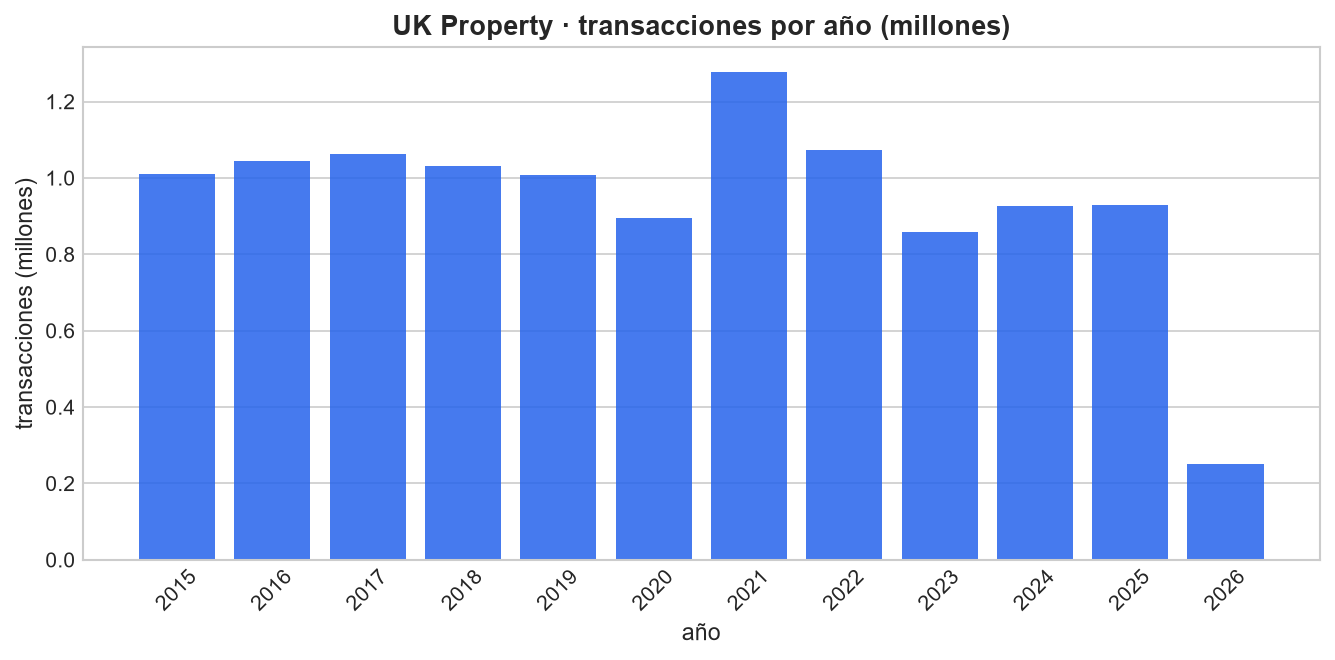

In [6]:
graficos.presentar(graficos.transacciones_por_anio(df))

## 8. Muestras TOP / BOTTOM

Verificación de formato, codificación y contenido de las principales columnas.

In [7]:
df.head(3)

,transaction_id,price,date_of_transfer,year,month,quarter,postcode,postcode_outward,property_type_full,duration_full,is_new_build,town_city,district,county,ppd_category_type,latitude,longitude,region,country,admin_district
0,{98C75471-910D-72E9-E053-6B04A8C042F0},161995,2019-09-27,2019,9,3,WA7 2RY,WA7,Semi-Detached,Freehold,False,RUNCORN,HALTON,HALTON,A,53.326997,-2.714006,North West,England,Halton
1,{47844C7F-CE8E-8986-E050-A8C063056488},220000,2016-12-15,2016,12,4,EN8 7FG,EN8,Flat/Maisonette,Leasehold,True,WALTHAM CROSS,BROXBOURNE,HERTFORDSHIRE,A,51.700200,-0.039072,East of England,England,Broxbourne
2,{34428D7E-D047-B86C-E050-A8C06205059C},141000,2016-01-08,2016,1,1,PO4 8EW,PO4,Flat/Maisonette,Leasehold,True,SOUTHSEA,PORTSMOUTH,PORTSMOUTH,B,50.796785,-1.059415,South East,England,Portsmouth


In [8]:
df.tail(3)

,transaction_id,price,date_of_transfer,year,month,quarter,postcode,postcode_outward,property_type_full,duration_full,is_new_build,town_city,district,county,ppd_category_type,latitude,longitude,region,country,admin_district
11369410,{2D4D7609-A8DC-BDF9-E063-4804A8C0672F},95000,2024-12-16,2024,12,4,B74 4BH,B74,Flat/Maisonette,Leasehold,False,SUTTON COLDFIELD,BIRMINGHAM,WEST MIDLANDS,A,52.601074,-1.848686,West Midlands,England,Birmingham
11369411,{C18F412B-4D5E-81A6-E053-6B04A8C0AD18},90000,2021-02-15,2021,2,1,TA21 9BJ,TA21,Terraced,Leasehold,False,WELLINGTON,SOMERSET WEST AND TAUNTON,SOMERSET,A,50.975887,-3.275677,South West,England,Somerset
11369412,{C18F412B-24F7-81A6-E053-6B04A8C0AD18},475000,2021-03-10,2021,3,1,NN4 6JD,NN4,Detached,Freehold,False,NORTHAMPTON,WEST NORTHAMPTONSHIRE,WEST NORTHAMPTONSHIRE,A,52.206321,-0.893765,East Midlands,England,West Northamptonshire


## Cierre

Lectura completada: **20 columnas × ~11,37 M de filas**, único origen del proyecto. El diagnóstico formal y la limpieza viven en `libros/Diagnostico_Limpieza.ipynb`.